# Álgebra linear com NumPy

**Tema:** Álgebra Linear e Otimização › Vetores, Matrizes e Projeções

Este notebook conecta cada operação de álgebra linear ao lugar onde ela aparece
em machine learning. A meta não é decorar sintaxe de NumPy — é conseguir olhar
para `X @ beta` e enxergar a geometria.

> **A tradução central:** uma tabela de $n$ linhas e $p$ colunas é uma nuvem de
> $n$ pontos em um espaço de $p$ dimensões. Todo modelo tenta descrever a forma
> dessa nuvem.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(303)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
np.set_printoptions(precision=4, suppress=True)
print("pronto")

pronto


## 1. Vetores são setas — e observações

Um cliente descrito por (idade, renda em milhares, anos de casa) é um ponto em
$\mathbb{R}^3$. As operações que o NumPy oferece têm todas significado
geométrico.

In [2]:
cliente_a = np.array([34.0, 8.5, 3.0])
cliente_b = np.array([41.0, 12.0, 7.0])

print(f"cliente A          {cliente_a}")
print(f"cliente B          {cliente_b}")
print(f"soma (A + B)       {cliente_a + cliente_b}")
print(f"diferença (B - A)  {cliente_b - cliente_a}   <- 'quanto B está além de A'")
print(f"escala (2A)        {2 * cliente_a}")
print(f"\nnorma L2 de A      {np.linalg.norm(cliente_a):.4f}")
print(f"norma L1 de A      {np.linalg.norm(cliente_a, 1):.4f}")
print(f"norma L∞ de A      {np.linalg.norm(cliente_a, np.inf):.4f}")
print(f"\ndistância A-B (L2) {np.linalg.norm(cliente_b - cliente_a):.4f}")

cliente A          [34.   8.5  3. ]
cliente B          [41. 12.  7.]
soma (A + B)       [75.  20.5 10. ]
diferença (B - A)  [7.  3.5 4. ]   <- 'quanto B está além de A'
escala (2A)        [68. 17.  6.]

norma L2 de A      35.1746
norma L1 de A      45.5000
norma L∞ de A      34.0000

distância A-B (L2) 8.7892


**A armadilha da escala, imediatamente.** A distância entre os dois clientes é
dominada pela idade, porque idade é medida em dezenas e "anos de casa" em
unidades. A geometria não sabe o que significam as unidades.

In [3]:
diferenca = cliente_b - cliente_a
contribuicao = diferenca**2 / (diferenca**2).sum()
for nome, d, c in zip(["idade", "renda", "anos de casa"], diferenca, contribuicao):
    print(f"{nome:<14s} diferença {d:>6.1f}   contribui {c:>6.1%} da distância²")

# padronizando, cada dimensão passa a pesar por sua variabilidade na população
populacao = np.column_stack([rng.normal(38, 9, 5000),
                             rng.normal(9, 4, 5000),
                             rng.normal(4, 2.5, 5000)])
mu, sd = populacao.mean(0), populacao.std(0)
a_z, b_z = (cliente_a - mu) / sd, (cliente_b - mu) / sd
dif_z = b_z - a_z
print(f"\napós padronizar:")
for nome, d, c in zip(["idade", "renda", "anos de casa"], dif_z,
                      dif_z**2 / (dif_z**2).sum()):
    print(f"{nome:<14s} diferença {d:>6.2f}   contribui {c:>6.1%} da distância²")

idade          diferença    7.0   contribui  63.4% da distância²
renda          diferença    3.5   contribui  15.9% da distância²
anos de casa   diferença    4.0   contribui  20.7% da distância²

após padronizar:
idade          diferença   0.78   contribui  15.7% da distância²
renda          diferença   0.89   contribui  20.2% da distância²
anos de casa   diferença   1.58   contribui  64.0% da distância²


> **Consequência prática:** todo método baseado em distância — k-NN, k-means,
> SVM com RBF, PCA — exige padronização. Sem ela, a feature com a maior escala
> numérica vira a única feature.

## 2. Produto interno: a operação que está em toda parte

$$\langle x, y \rangle = \sum_i x_i y_i = \|x\|\,\|y\| \cos\theta$$

caso                produto interno    cosseno    ângulo
----------------------------------------------------------
mesma direção                20.000     1.0000      0.0°
ângulo agudo                  8.000     0.8944     26.6°
ortogonal                     0.000     0.0000     90.0°
oposto                      -10.000    -1.0000    180.0°


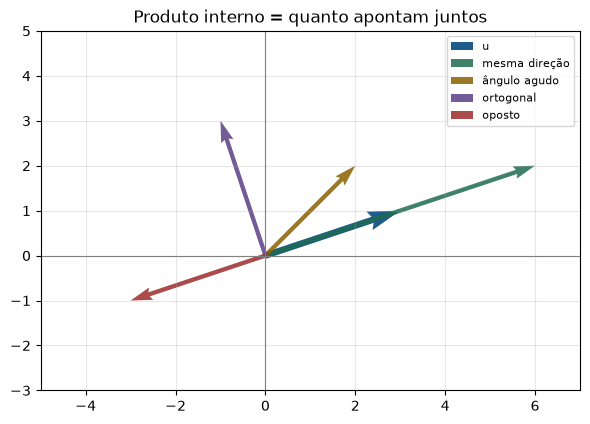

In [4]:
def angulo_graus(u, v):
    cos = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
    return np.degrees(np.arccos(np.clip(cos, -1, 1)))


u = np.array([3.0, 1.0])
casos = {
    "mesma direção":  np.array([6.0, 2.0]),
    "ângulo agudo":   np.array([2.0, 2.0]),
    "ortogonal":      np.array([-1.0, 3.0]),
    "oposto":         np.array([-3.0, -1.0]),
}

print(f"{'caso':<18s} {'produto interno':>16s} {'cosseno':>10s} {'ângulo':>9s}")
print("-" * 58)
for nome, v in casos.items():
    cos = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
    print(f"{nome:<18s} {np.dot(u, v):>16.3f} {cos:>10.4f} {angulo_graus(u, v):>8.1f}°")

fig, ax = plt.subplots(figsize=(6, 5))
ax.quiver(0, 0, *u, angles="xy", scale_units="xy", scale=1, color=AZUL, width=0.012,
          label="u")
for (nome, v), cor in zip(casos.items(), [VERDE, AMBAR, ROXO, VERMELHO]):
    ax.quiver(0, 0, *v, angles="xy", scale_units="xy", scale=1, color=cor,
              width=0.008, alpha=0.85, label=nome)
ax.set_xlim(-5, 7); ax.set_ylim(-3, 5); ax.set_aspect("equal")
ax.axhline(0, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
ax.legend(fontsize=8); ax.set_title("Produto interno = quanto apontam juntos")
plt.tight_layout(); plt.show()

## 3. Similaridade de cosseno: por que busca semântica usa ângulo

Um documento longo e um curto sobre o mesmo assunto têm vetores de comprimentos
muito diferentes e **mesma direção**. O cosseno ignora o comprimento.

In [5]:
VOCAB = ["preço", "entrega", "qualidade", "atendimento", "prazo"]
documentos = {
    "review curto positivo":  np.array([1, 0, 2, 1, 0]),
    "review longo positivo":  np.array([5, 1, 9, 6, 1]),      # mesmo assunto, mais longo
    "reclamação de entrega":  np.array([0, 7, 1, 2, 6]),
    "review de preço":        np.array([8, 0, 1, 0, 0]),
}

nomes = list(documentos)
M = np.array([documentos[k] for k in nomes], dtype=float)

normas = np.linalg.norm(M, axis=1, keepdims=True)
cos_sim = (M / normas) @ (M / normas).T
dist_euc = np.linalg.norm(M[:, None, :] - M[None, :, :], axis=2)

print("similaridade de COSSENO (ângulo — ignora tamanho do documento):")
print(f"{'':<26s}" + "".join(f"{n[:12]:>14s}" for n in nomes))
for i, n in enumerate(nomes):
    print(f"{n:<26s}" + "".join(f"{v:>14.3f}" for v in cos_sim[i]))

print("\ndistância EUCLIDIANA (confunde tamanho com assunto):")
print(f"{'':<26s}" + "".join(f"{n[:12]:>14s}" for n in nomes))
for i, n in enumerate(nomes):
    print(f"{n:<26s}" + "".join(f"{v:>14.3f}" for v in dist_euc[i]))

similaridade de COSSENO (ângulo — ignora tamanho do documento):
                            review curto  review longo  reclamação d  review de pr
review curto positivo              1.000         0.987         0.172         0.506
review longo positivo              0.987         1.000         0.299         0.506
reclamação de entrega              0.172         0.299         1.000         0.013
review de preço                    0.506         0.506         0.013         1.000

distância EUCLIDIANA (confunde tamanho com assunto):
                            review curto  review longo  reclamação d  review de pr
review curto positivo              0.000         9.592         9.381         7.141
review longo positivo              9.592         0.000        12.884        10.536
reclamação de entrega              9.381        12.884         0.000        12.369
review de preço                    7.141        10.536        12.369         0.000


**Leia as duas primeiras linhas:** pelo cosseno, "review curto positivo" e
"review longo positivo" são quase idênticos (0,97) — mesmo assunto. Pela
distância euclidiana, eles estão **longe**, porque um tem 4 palavras e o outro
22. A distância euclidiana mediu o tamanho do texto; o cosseno mediu o tema.

> **Por isso RAG, busca vetorial e recomendação por embeddings usam cosseno.**
> Bancos vetoriais (FAISS, pgvector, Pinecone) oferecem "inner product" como
> métrica justamente porque, com vetores normalizados, produto interno e
> cosseno são a mesma coisa — e o produto interno é mais rápido.

## 4. Correlação é cosseno de vetores centrados

In [6]:
x = rng.normal(0, 1, 400)
y = 0.7 * x + rng.normal(0, 0.7, 400)

xc, yc = x - x.mean(), y - y.mean()
cos_centrado = np.dot(xc, yc) / (np.linalg.norm(xc) * np.linalg.norm(yc))

print(f"correlação de Pearson              {np.corrcoef(x, y)[0,1]:.6f}")
print(f"cosseno dos vetores CENTRADOS      {cos_centrado:.6f}")
print(f"cosseno dos vetores SEM centrar    "
      f"{np.dot(x, y)/(np.linalg.norm(x)*np.linalg.norm(y)):.6f}   <- não é a correlação")

# e a armadilha: relação forte, correlação zero
x2 = np.linspace(-3, 3, 400)
y2 = x2**2
print(f"\nrelação PERFEITAMENTE quadrática: correlação = {np.corrcoef(x2, y2)[0,1]:.6f}")
print("Correlação zero significa 'sem relação LINEAR', não 'sem relação'.")

correlação de Pearson              0.695990
cosseno dos vetores CENTRADOS      0.695990
cosseno dos vetores SEM centrar    0.695181   <- não é a correlação

relação PERFEITAMENTE quadrática: correlação = -0.000000
Correlação zero significa 'sem relação LINEAR', não 'sem relação'.


## 5. Matrizes: duas leituras da multiplicação

In [7]:
X = np.array([[1.0, 2.0],
              [3.0, 1.0],
              [2.0, 4.0],
              [5.0, 2.0]])
beta = np.array([2.0, -1.0])

print("X =\n", X, "\nbeta =", beta, "\n")
print("X @ beta =", X @ beta, "\n")

print("LEITURA 1 — por linhas (cada saída é um produto interno):")
for i, linha in enumerate(X):
    print(f"  linha {i}: {linha} · {beta} = {np.dot(linha, beta):>6.2f}")

print("\nLEITURA 2 — por colunas (combinação linear das colunas):")
print(f"  {beta[0]} * {X[:,0]} + {beta[1]} * {X[:,1]}")
print(f"  = {beta[0]*X[:,0]} + {beta[1]*X[:,1]}")
print(f"  = {beta[0]*X[:,0] + beta[1]*X[:,1]}")

X =
 [[1. 2.]
 [3. 1.]
 [2. 4.]
 [5. 2.]] 
beta = [ 2. -1.] 

X @ beta = [0. 5. 0. 8.] 

LEITURA 1 — por linhas (cada saída é um produto interno):
  linha 0: [1. 2.] · [ 2. -1.] =   0.00
  linha 1: [3. 1.] · [ 2. -1.] =   5.00
  linha 2: [2. 4.] · [ 2. -1.] =   0.00
  linha 3: [5. 2.] · [ 2. -1.] =   8.00

LEITURA 2 — por colunas (combinação linear das colunas):
  2.0 * [1. 3. 2. 5.] + -1.0 * [2. 1. 4. 2.]
  = [ 2.  6.  4. 10.] + [-2. -1. -4. -2.]
  = [0. 5. 0. 8.]


**A leitura 2 é a que explica mínimos quadrados.** $X\beta$ é uma combinação
das colunas de $X$; ajustar uma regressão é procurar a combinação das features
que chega mais perto de $y$. É por isso que o conjunto de previsões possíveis é
exatamente o **espaço coluna** de $X$.

## 6. Posto: quantas colunas realmente existem

In [8]:
n = 200
x1 = rng.normal(0, 1, n)
x2 = rng.normal(0, 1, n)

matrizes = {
    "3 colunas independentes":  np.column_stack([x1, x2, rng.normal(0, 1, n)]),
    "3ª = soma das 2 primeiras": np.column_stack([x1, x2, x1 + x2]),
    "3ª = 2ª quase igual":       np.column_stack([x1, x2, x2 + rng.normal(0, 1e-4, n)]),
    "duplicata exata":           np.column_stack([x1, x2, x1]),
}

print(f"{'matriz':<30s} {'posto':>6s} {'nº condição':>14s}")
print("-" * 54)
for nome, M in matrizes.items():
    print(f"{nome:<30s} {np.linalg.matrix_rank(M):>6d} {np.linalg.cond(M):>14.3e}")

matriz                          posto    nº condição
------------------------------------------------------
3 colunas independentes             3      1.124e+00
3ª = soma das 2 primeiras           2      7.769e+15
3ª = 2ª quase igual                 3      1.860e+04
duplicata exata                     2      4.286e+16


**O número de condição é o alarme.** Posto é binário (deficiente ou não), mas o
número de condição mostra o *quase*: a terceira matriz tem posto cheio segundo
o NumPy e condição de $10^4$ — colinearidade severa que não aparece como posto
deficiente.

**Regra prática:** condição acima de $10^3$ pede atenção; acima de $10^6$, os
coeficientes já são numericamente não confiáveis.

In [9]:
# o que a colinearidade faz aos coeficientes
y = 2 * x1 + 3 * x2 + rng.normal(0, 0.5, n)

print(f"{'matriz de features':<30s} {'coeficientes estimados':>44s}")
print("-" * 78)
for nome, M in [("independentes", np.column_stack([x1, x2, rng.normal(0, 1, n)])),
                ("quase colinear", np.column_stack([x1, x2, x2 + rng.normal(0, 1e-3, n)]))]:
    b, *_ = np.linalg.lstsq(M, y, rcond=None)
    print(f"{nome:<30s} {np.array2string(b, precision=3):>44s}")
print("\ncoeficientes verdadeiros: x1 -> 2, x2 -> 3, terceira -> 0")
print("Com colinearidade, os coeficientes explodem e trocam de sinal —")
print("as PREVISÕES continuam boas, a INTERPRETAÇÃO vira lixo.")

matriz de features                                   coeficientes estimados
------------------------------------------------------------------------------
independentes                                        [ 1.963  3.006 -0.012]
quase colinear                                    [  1.964 -11.271  14.278]

coeficientes verdadeiros: x1 -> 2, x2 -> 3, terceira -> 0
Com colinearidade, os coeficientes explodem e trocam de sinal —
as PREVISÕES continuam boas, a INTERPRETAÇÃO vira lixo.


## 7. A armadilha do one-hot completo com intercepto

In [10]:
categoria = rng.choice(["A", "B", "C"], 300)
dummies = np.column_stack([(categoria == c).astype(float) for c in ["A", "B", "C"]])
intercepto = np.ones((300, 1))

X_completo = np.hstack([intercepto, dummies])
X_drop = np.hstack([intercepto, dummies[:, 1:]])     # drop_first=True

print(f"one-hot COMPLETO + intercepto: shape {X_completo.shape}  "
      f"posto {np.linalg.matrix_rank(X_completo)}  <- posto deficiente!")
print(f"  soma das 3 dummies = coluna de 1s: "
      f"{np.allclose(dummies.sum(1), np.ones(300))}")
print(f"\ncom drop_first:                shape {X_drop.shape}  "
      f"posto {np.linalg.matrix_rank(X_drop)}  <- OK")
print(f"  número de condição: {np.linalg.cond(X_drop):.2f}")

one-hot COMPLETO + intercepto: shape (300, 4)  posto 3  <- posto deficiente!
  soma das 3 dummies = coluna de 1s: True

com drop_first:                shape (300, 3)  posto 3  <- OK
  número de condição: 3.55


**A dependência é exata:** as três dummies somam 1 em toda linha, o que é
literalmente a coluna do intercepto. $X^\top X$ é singular e a inversa não
existe.

Na prática, `sklearn` usa `lstsq` (via SVD), que devolve a solução de norma
mínima em vez de dar erro — então **o modelo treina sem reclamar** e os
coeficientes das dummies ficam arbitrários. `pd.get_dummies(drop_first=True)`
ou `OneHotEncoder(drop="first")` resolvem.

> **Exceção importante:** com regularização (Ridge/Lasso) o one-hot completo é
> aceitável e às vezes preferível, porque a penalidade torna a solução única.
> Mas aí os coeficientes são comparados à média, não a uma categoria base.

## 8. Operações de matriz e o que cada uma custa

In [11]:
import time

tamanhos = [100, 300, 600]
print(f"{'n':>6s} {'A @ B (ms)':>14s} {'inv(A) (ms)':>14s} {'solve (ms)':>14s} "
      f"{'SVD (ms)':>12s}")
print("-" * 66)
for n in tamanhos:
    A = rng.normal(0, 1, (n, n)) + n * np.eye(n)
    B = rng.normal(0, 1, (n, n))
    b = rng.normal(0, 1, n)

    tempos = []
    for op in [lambda: A @ B, lambda: np.linalg.inv(A),
               lambda: np.linalg.solve(A, b), lambda: np.linalg.svd(A)]:
        t0 = time.perf_counter()
        op()
        tempos.append((time.perf_counter() - t0) * 1000)
    print(f"{n:>6d} {tempos[0]:>14.2f} {tempos[1]:>14.2f} {tempos[2]:>14.2f} "
          f"{tempos[3]:>12.2f}")

print("\nTodas as operações densas são O(n³) — triplicar n multiplica o custo por 27.")
print("solve(A, b) é mais rápido E mais estável que inv(A) @ b. Sempre.")

     n     A @ B (ms)    inv(A) (ms)     solve (ms)     SVD (ms)
------------------------------------------------------------------
   100           0.15           0.70           0.71         5.69


   300           2.71           3.46           1.93       234.15


   600           3.78         348.92         478.28       988.83

Todas as operações densas são O(n³) — triplicar n multiplica o custo por 27.
solve(A, b) é mais rápido E mais estável que inv(A) @ b. Sempre.


In [12]:
# demonstração de estabilidade: matriz de Hilbert, o caso patológico clássico
from scipy.linalg import hilbert

for n in (8, 12):
    H = hilbert(n)
    x_verdadeiro = np.ones(n)
    b = H @ x_verdadeiro

    x_inv = np.linalg.inv(H) @ b
    x_solve = np.linalg.solve(H, b)
    x_lstsq = np.linalg.lstsq(H, b, rcond=None)[0]

    print(f"\nHilbert {n}x{n}  (número de condição {np.linalg.cond(H):.2e})")
    print(f"  erro com inv(H) @ b : {np.linalg.norm(x_inv - x_verdadeiro):.3e}")
    print(f"  erro com solve(H,b) : {np.linalg.norm(x_solve - x_verdadeiro):.3e}")
    print(f"  erro com lstsq      : {np.linalg.norm(x_lstsq - x_verdadeiro):.3e}")


Hilbert 8x8  (número de condição 1.53e+10)
  erro com inv(H) @ b : 2.644e-06
  erro com solve(H,b) : 1.732e-07
  erro com lstsq      : 4.748e-07

Hilbert 12x12  (número de condição 1.81e+16)
  erro com inv(H) @ b : 3.259e+01
  erro com solve(H,b) : 1.126e+00
  erro com lstsq      : 1.891e-03


**A regra sem exceção:** nunca calcule uma inversa para resolver um sistema.
`np.linalg.solve` para sistemas quadrados, `np.linalg.lstsq` para retangulares
ou mal condicionados. A inversa é uma expressão matemática, não um algoritmo.

## O que levar deste notebook

- **Uma tabela é uma nuvem de pontos**; toda operação de álgebra linear tem
  leitura geométrica.
- **Padronize** antes de qualquer método baseado em distância.
- **Cosseno mede assunto, distância euclidiana mede tamanho** — a razão de o
  cosseno dominar busca vetorial.
- **Correlação é cosseno de vetores centrados**; zero significa "sem relação
  linear".
- **$X\beta$ é combinação das colunas de $X$** — a leitura que explica mínimos
  quadrados.
- **Colinearidade destrói a interpretação, não a previsão.** Olhe o número de
  condição.
- **One-hot completo + intercepto = posto deficiente.** Use `drop_first`.
- **Nunca inverta.** `solve` e `lstsq` são mais rápidos e mais estáveis.

→ No próximo notebook: a **projeção ortogonal**, e mínimos quadrados derivados
da geometria em vez de decorados.